# 10 &middot; Resolution and Cost: the Accuracy/Speed Trade-off

Refining the mesh improves accuracy but makes every solve more expensive. We
measure both on a cantilever sagging under gravity:

* **cost**: Newton-solve time vs. vertex count (10 resolutions),
* **accuracy**: tip deflection converging to a very fine reference,
* the punchline: a super-fine mesh is accurate but **too slow to iterate on.**

In [1]:
%matplotlib inline
import time
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
from simkit.solvers import newton_solver
import utils

## A timed static solve at any resolution

`GravityBeam` is our standard static simulator: it builds the mesh, precomputes
the per-mesh constants once, and composes three energy terms &mdash; the elastic
material, a fixed **pin** on the left edge, and **gravity** &mdash; summing them
one per line. The beam is soft enough ($E = 800$) that the sag is large and
obvious. `gravity_scale` lets us ramp gravity for the animation, and `.solve()`
returns the settled equilibrium.

In [2]:
class GravityBeam:
    """Cantilever sagging under gravity: elastic + pin + gravity, solved with Newton."""

    def __init__(self, nx, ny):
        X, T = utils.triangulated_grid(nx, ny, width=2.0, height=0.3)
        self.X, self.T = X, T
        self.p   = utils.precompute(X, T, ym=800.0, pr=0.4, rho=1.0, gravity=-9.8)
        self.psi = utils.make_material("Neo-Hookean")
        pin_idx  = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
        self.pin = utils.PenaltySpring(self.p.n, self.p.dim, 1e7).set(pin_idx, X[pin_idx])
        self.gravity = utils.Gravity(self.p.f_g)

    def energy(self, x):
        E_elastic = self.psi.energy(x, self.p)
        E_pin     = self.pin.energy(x)
        E_gravity = self.gravity.energy(x)
        return E_elastic + E_pin + E_gravity

    def gradient(self, x):
        g_elastic = self.psi.gradient(x, self.p)
        g_pin     = self.pin.gradient(x)
        g_gravity = self.gravity.gradient(x)
        return g_elastic + g_pin + g_gravity

    def hessian(self, x):
        H_elastic = self.psi.hessian(x, self.p)
        H_pin     = self.pin.hessian(x)
        return H_elastic + H_pin

    def solve(self, iters=30):
        x = newton_solver(self.X.reshape(-1, 1), self.energy, self.gradient, self.hessian,
                          max_iter=iters, do_line_search=True)
        return x.reshape(self.p.n, self.p.dim)

## Cost and accuracy across 10 resolutions

We loop **explicitly** over ten resolutions: build a `GravityBeam`, time its
`.solve()` with `time.perf_counter`, and record the vertex count, solve time,
and tip deflection (the $y$ of the right-most vertex). A very fine mesh serves
as the "ground truth" tip deflection, and the **error** of each run is its tip
deflection's distance from that reference.

In [3]:
resolutions = [(5, 2), (7, 3), (10, 4), (14, 5), (19, 6), (26, 9), (34, 11), (44, 15), (56, 19), (70, 23)]

verts, times, tips = [], [], []
for nx, ny in resolutions:
    beam = GravityBeam(nx, ny)
    t0 = time.perf_counter()
    U = beam.solve()
    dt = time.perf_counter() - t0
    verts.append(beam.p.n)
    times.append(dt)
    tips.append(U[int(np.argmax(beam.X[:, 0])), 1])

ref_beam = GravityBeam(90, 30)                       # fine "ground truth"
t0 = time.perf_counter()
ref_U = ref_beam.solve()
ref_time = time.perf_counter() - t0
ref_tip  = ref_U[int(np.argmax(ref_beam.X[:, 0])), 1]
print(f"fine reference: {ref_beam.p.n} verts, {ref_time*1000:.0f} ms, tip_y = {ref_tip:.4f}")

verts  = np.array(verts)
times  = np.array(times)
errors = np.array([abs(t - ref_tip) for t in tips])
for n, dt, ty, e in zip(verts, times, tips, errors):
    print(f"  {n:5d} verts   {dt*1000:7.1f} ms   tip_y {ty:.4f}   error {e:.2e}")

fine reference: 2700 verts, 639 ms, tip_y = -1.5929
     10 verts       3.0 ms   tip_y -0.6471   error 9.46e-01
     21 verts       6.0 ms   tip_y -1.0354   error 5.57e-01
     40 verts      11.4 ms   tip_y -1.2861   error 3.07e-01
     70 verts      14.5 ms   tip_y -1.4194   error 1.73e-01
    114 verts      22.5 ms   tip_y -1.4883   error 1.05e-01
    234 verts      38.0 ms   tip_y -1.5424   error 5.05e-02
    374 verts      63.8 ms   tip_y -1.5629   error 3.00e-02
    660 verts     127.8 ms   tip_y -1.5772   error 1.56e-02
   1064 verts     207.3 ms   tip_y -1.5849   error 8.00e-03
   1610 verts     300.5 ms   tip_y -1.5894   error 3.52e-03


## Compute time vs resolution, and accuracy vs resolution

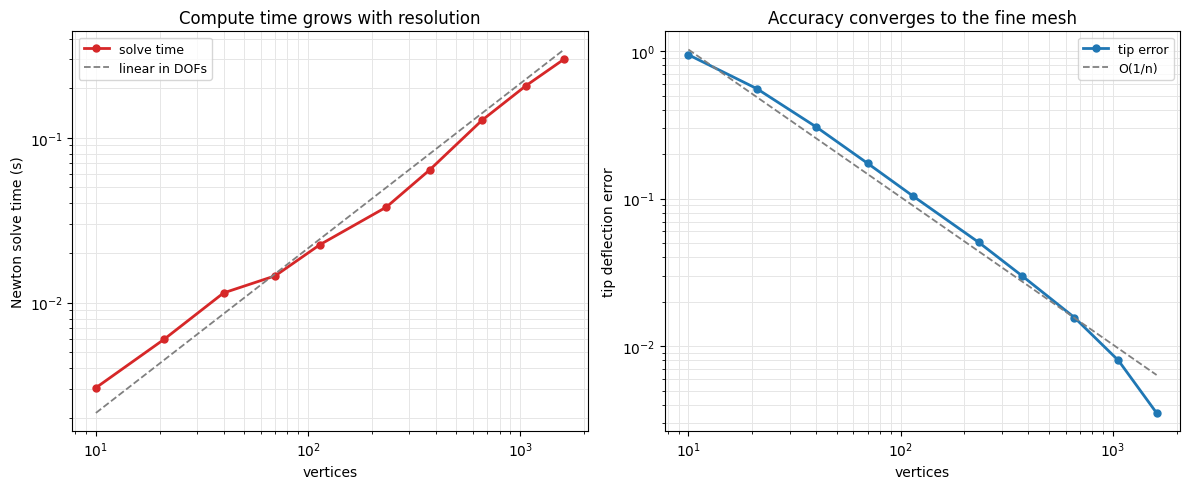

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
utils.loglog_plot(verts, {"solve time": times}, xlabel="vertices", ylabel="Newton solve time (s)",
    colors={"solve time": "#d62728"}, ref_slopes={"linear in DOFs": 1},
    title="Compute time grows with resolution", markers=True, ax=axes[0])
utils.loglog_plot(verts, {"tip error": errors}, xlabel="vertices", ylabel="tip deflection error",
    colors={"tip error": "#1f77b4"}, ref_slopes={"O(1/n)": -1},
    title="Accuracy converges to the fine mesh", markers=True, ax=axes[1])
fig.tight_layout(); plt.show()

## Watching three resolutions sag (clearly!) under gravity

Ramp gravity $0 \rightarrow 1$ and solve each frame for three resolutions, then **hold
at full gravity** so every beam settles to its final equilibrium and visibly
comes to rest. They converge to nearly the same big droop &mdash; but the finest
one took far longer per frame.

In [5]:
ramp = np.concatenate([np.linspace(0.0, 1.0, 22), np.ones(12)])   # ramp up, then hold at rest
panels = []
for nx, ny, label in [(7, 3, "coarse"), (16, 6, "medium"), (32, 11, "fine")]:
    beam = GravityBeam(nx, ny)
    f_g_full = beam.p.f_g.copy()                                  # scale gravity for the ramp
    states = []
    for g in ramp:
        beam.gravity.f_g = g * f_g_full
        states.append(beam.solve())
    panels.append({"states": states, "T": beam.T,
                   "title": f"{label}  ({beam.p.n} verts)"})

fig, anim = utils.animate_meshes_grid(panels, lims=((-1.2, 1.2), (-1.8, 0.3)), fps=20,
    suptitle="Same beam, three resolutions, sagging under gravity")
utils.show_video(fig, anim, "media/10_resolution.mp4", fps=20)

## Why "just refine it" is a trap

In [6]:
i_good = 4                                            # a mid-resolution mesh
rel = errors[i_good] / abs(ref_tip)
print(f"good-enough ({verts[i_good]:5d} verts): {times[i_good]*1000:8.1f} ms/solve   ({rel*100:.0f}% tip error)")
print(f"fine        ({ref_beam.p.n:5d} verts): {ref_time*1000:8.1f} ms/solve")
print(f"\nThe fine mesh is ~{ref_time/times[i_good]:.0f}x slower per solve for a tip deflection")
print(f"within {rel*100:.0f}% of it. Interactive editing (many solves/second) is impossible")
print("long before that accuracy is worth it -- pick the coarsest mesh that captures the behavior.")

good-enough (  114 verts):     22.5 ms/solve   (7% tip error)
fine        ( 2700 verts):    638.8 ms/solve

The fine mesh is ~28x slower per solve for a tip deflection
within 7% of it. Interactive editing (many solves/second) is impossible
long before that accuracy is worth it -- pick the coarsest mesh that captures the behavior.


### Takeaways
* **Cost** rises steeply with vertex count; each Newton step solves a bigger
  sparse system.
* **Accuracy** improves with resolution but with diminishing returns.
* A super-fine mesh is accurate yet **too slow to iterate on**.

---
That completes the offline SimKit tutorial series (1&ndash;10): building and
understanding the deformation gradient, elastic energies, the elastostatic
minimization, the solvers and line search that drive it, time integration,
contact, and the resolution/cost trade-off.